In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Load a Biased Dataset (UCI Adult Income)
# Data can be downloaded from UCI repository or directly loaded if available via a library
# For simplicity, let's assume we are loading from a URL or a local file.
# The column names are usually provided separately or need to be inferred.

# Column names for the Adult dataset (from UCI Machine Learning Repository)
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]

# Load the dataset from a URL
try:
    df = pd.read_csv(
        'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data',
        names=column_names,
        na_values=['?'], # Handle '?' as missing values
        skipinitialspace=True
    )
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Attempting to load from a common local path if available...")
    # Fallback for local testing or if URL fails
    # Make sure 'adult.data' is in the same directory or specified path
    df = pd.read_csv(
        '/content/adult.data',
        names=column_names,
        na_values=['?'],
        skipinitialspace=True
    )

print("Dataset loaded successfully.")
print(f"Initial shape: {df.shape}")

# Clean up whitespace in categorical columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

# 2. Define Attributes
TARGET_VARIABLE = 'income'
# Convert target to binary (0 or 1)
df[TARGET_VARIABLE] = df[TARGET_VARIABLE].apply(lambda x: 1 if x == '>50K' else 0)

SENSITIVE_ATTRIBUTE = 'sex' # Another common choice is 'race'

print(f"Target variable: {TARGET_VARIABLE}, Sensitive attribute: {SENSITIVE_ATTRIBUTE}")
print(f"Target distribution:\n{df[TARGET_VARIABLE].value_counts(normalize=True)}")
print(f"Sensitive attribute distribution:\n{df[SENSITIVE_ATTRIBUTE].value_counts(normalize=True)}")

# Identify numerical and categorical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Remove target variable from numerical features if it was initially numerical
if TARGET_VARIABLE in numerical_features:
    numerical_features.remove(TARGET_VARIABLE)

categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical features: {numerical_features}")
print(f"Categorical features: {categorical_features}")

# 3. Pre-processing Pipeline

# Preprocessing for numerical features: impute missing values with mean and then scale
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical features: impute missing values with most frequent and then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Separate features (X) and target (y)
X = df.drop(columns=[TARGET_VARIABLE])
y = df[TARGET_VARIABLE]

# 4. Train/Test Split
# Crucial: Keep the test set unmodified for evaluating all models
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Apply preprocessing to the training data
X_train_processed = preprocessor.fit_transform(X_train)

# For the test data, we only transform, not fit, to avoid data leakage
X_test_processed = preprocessor.transform(X_test)

print("\nData preprocessing and train/test split complete.")
print("X_train_processed and X_test_processed contain the processed features.")
print("X_test and y_test are kept untouched for consistent model evaluation.")

# You can inspect the shapes of the processed data
print(f"Shape of processed X_train: {X_train_processed.shape}")
print(f"Shape of processed X_test: {X_test_processed.shape}")

Dataset loaded successfully.
Initial shape: (32561, 15)
Target variable: income, Sensitive attribute: sex
Target distribution:
income
0    0.75919
1    0.24081
Name: proportion, dtype: float64
Sensitive attribute distribution:
sex
Male      0.669205
Female    0.330795
Name: proportion, dtype: float64
Numerical features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

Shape of X_train: (26048, 14)
Shape of X_test: (6513, 14)
Shape of y_train: (26048,)
Shape of y_test: (6513,)

Data preprocessing and train/test split complete.
X_train_processed and X_test_processed contain the processed features.
X_test and y_test are kept untouched for consistent model evaluation.
Shape of processed X_train: (26048, 105)
Shape of processed X_test: (6513, 105)


## Phase 2: The Baseline Model (The Control)

This phase establishes a baseline by training a standard, unconstrained machine learning model and evaluating both its predictive performance and its fairness metrics. This will serve as a 'ground truth' to understand inherent biases before applying any mitigation strategies.

In [ ]:
!pip install fairlearn
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from fairlearn.metrics import MetricFrame, demographic_parity_difference, equalized_odds_difference

print("### Training Baseline Model (Logistic Regression) ###")

# 1. Train a standard, unconstrained machine learning model
# Using Logistic Regression as a common baseline
model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
model.fit(X_train_processed, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_processed)

print("\n### Evaluate Overall Performance ###")

# 2. Evaluate Performance: Calculate overall accuracy, precision, recall, and F1-score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Overall Accuracy: {accuracy:.4f}")
print(f"Overall Precision: {precision:.4f}")
print(f"Overall Recall: {recall:.4f}")
print(f"Overall F1-Score: {f1:.4f}")

print("\n### Evaluate Fairness ###")

# 3. Evaluate Fairness using fairlearn.metrics
# We need the sensitive attribute values from the *unprocessed* test set
sensitive_features_test = X_test[SENSITIVE_ATTRIBUTE]

# Create a MetricFrame to compute metrics across sensitive groups
# Difference metrics will be calculated separately
metric_frame = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'precision': precision_score,
        'recall': recall_score,
        'f1': f1_score
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_features_test
)

print("Fairness Metrics by Sensitive Attribute Group:")
display(metric_frame.by_group)

# Calculate difference metrics separately
dp_difference = demographic_parity_difference(y_test, y_pred, sensitive_features=sensitive_features_test)
eo_difference = equalized_odds_difference(y_test, y_pred, sensitive_features=sensitive_features_test)

print("\nFairness Differences:")
print(f"Demographic Parity Difference: {dp_difference:.4f}")
print(f"Equalized Odds Difference: {eo_difference:.4f}")

print("\nPhase 2 (Baseline Model) complete. The overall performance and fairness metrics have been calculated.")

### Training Baseline Model (Logistic Regression) ###

### Evaluate Overall Performance ###
Overall Accuracy: 0.8554
Overall Precision: 0.7393
Overall Recall: 0.6167
Overall F1-Score: 0.6725

### Evaluate Fairness ###
Fairness Metrics by Sensitive Attribute Group:


,accuracy,precision,recall,f1
sex,,,,
Female,0.929101,0.761364,0.546939,0.636580
Male,0.818829,0.735866,0.629630,0.678615



Fairness Differences:
Demographic Parity Difference: 0.1784
Equalized Odds Difference: 0.0827

Phase 2 (Baseline Model) complete. The overall performance and fairness metrics have been calculated.


### Visualizing Fairness Disparities

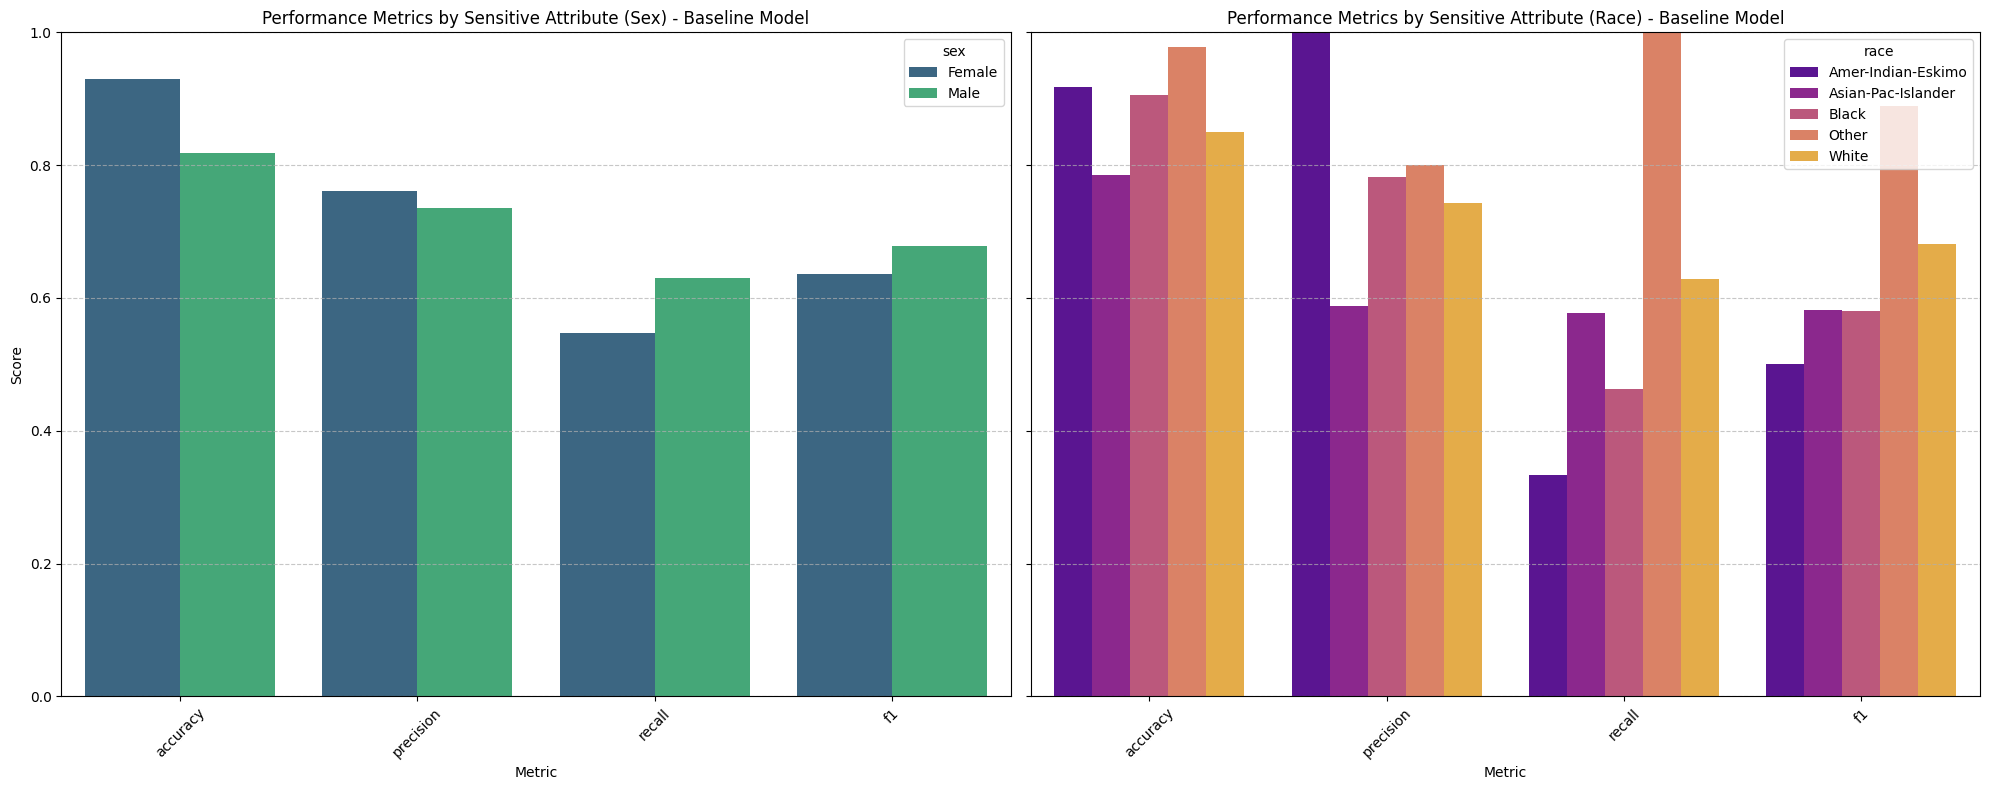

Disparity bar charts for 'sex' and 'race' generated in one figure.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert MetricFrame.by_group (sex) to a DataFrame for easier plotting
fairness_df_sex = metric_frame.by_group.reset_index()
fairness_df_sex = fairness_df_sex.melt(id_vars='sex', var_name='Metric', value_name='Score')

# We need the sensitive attribute values for 'race' from the *unprocessed* test set
sensitive_features_test_race = X_test['race']

# Create a MetricFrame to compute metrics across racial groups
metric_frame_race = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'precision': precision_score,
        'recall': recall_score,
        'f1': f1_score
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_features_test_race
)

# Convert MetricFrame.by_group for 'race' to a DataFrame for easier plotting
fairness_df_race = metric_frame_race.by_group.reset_index()
fairness_df_race = fairness_df_race.melt(id_vars='race', var_name='Metric', value_name='Score')

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

# Plot for 'sex' disparity
sns.barplot(x='Metric', y='Score', hue='sex', data=fairness_df_sex, palette='viridis', ax=axes[0])
axes[0].set_title('Performance Metrics by Sensitive Attribute (Sex) - Baseline Model')
axes[0].set_ylabel('Score')
axes[0].set_xlabel('Metric')
axes[0].set_ylim(0, 1) # Metrics are usually between 0 and 1
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].tick_params(axis='x', rotation=45)

# Plot for 'race' disparity
sns.barplot(x='Metric', y='Score', hue='race', data=fairness_df_race, palette='plasma', ax=axes[1])
axes[1].set_title('Performance Metrics by Sensitive Attribute (Race) - Baseline Model')
axes[1].set_ylabel('Score')
axes[1].set_xlabel('Metric')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Disparity bar charts for 'sex' and 'race' generated in one figure.")

### Calibration Curve Visualization

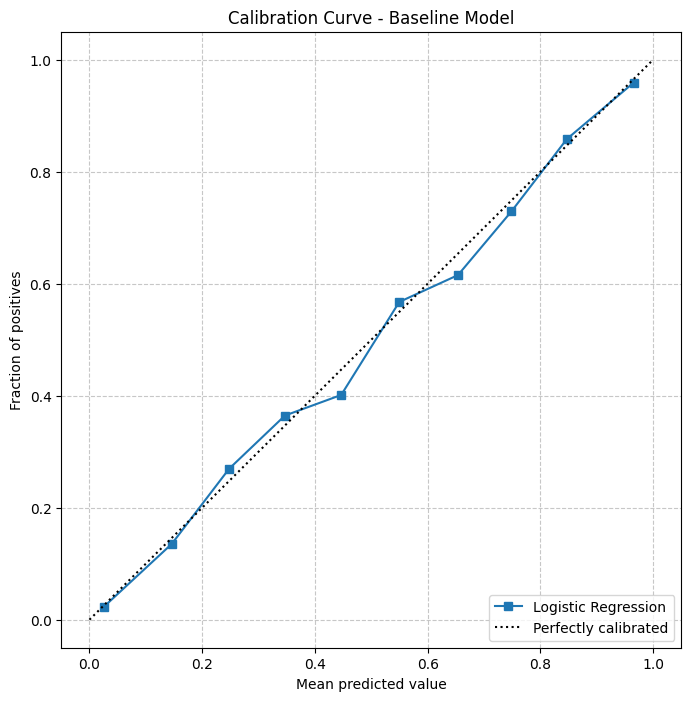

Calibration curve generated.


In [ ]:
from sklearn.calibration import calibration_curve

# Get predicted probabilities for the positive class
y_prob = model.predict_proba(X_test_processed)[:, 1]

# Calculate calibration curve data
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(8, 8))
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label="Logistic Regression")
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
plt.xlabel("Mean predicted value")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve - Baseline Model")
plt.legend(loc="lower right")
plt.grid(linestyle='--', alpha=0.7)
plt.show()

print("Calibration curve generated.")

### Visualizing Fairness Disparities by Race

In [ ]:
# We need the sensitive attribute values for 'race' from the *unprocessed* test set
sensitive_features_test_race = X_test['race']

# Create a MetricFrame to compute metrics across racial groups
metric_frame_race = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'precision': precision_score,
        'recall': recall_score,
        'f1': f1_score
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_features_test_race
)

print("Fairness Metrics by Sensitive Attribute Group (Race):")
display(metric_frame_race.by_group)

# Calculate difference metrics separately for race
dp_difference_race = demographic_parity_difference(y_test, y_pred, sensitive_features=sensitive_features_test_race)
eo_difference_race = equalized_odds_difference(y_test, y_pred, sensitive_features=sensitive_features_test_race)

print("\nFairness Differences (Race):")
print(f"Demographic Parity Difference (Race): {dp_difference_race:.4f}")
print(f"Equalized Odds Difference (Race): {eo_difference_race:.4f}")

print("Numerical fairness metrics for 'race' displayed.")

Fairness Metrics by Sensitive Attribute Group (Race):


,accuracy,precision,recall,f1
race,,,,
Amer-Indian-Eskimo,0.917808,1.000000,0.333333,0.500000
Asian-Pac-Islander,0.785000,0.588235,0.576923,0.582524
Black,0.906344,0.781818,0.462366,0.581081
Other,0.977778,0.800000,1.000000,0.888889
White,0.849991,0.742881,0.629078,0.681260



Fairness Differences (Race):
Demographic Parity Difference (Race): 0.2139
Equalized Odds Difference (Race): 0.6667
Numerical fairness metrics for 'race' displayed.


## Phase 3: Viewpoint C Implementation (The "Data is King" Realist)

This phase focuses on the idea that the model's bias might stem from an insufficient number of examples for the minority group within the training data. We'll use a data augmentation technique (SMOTE) to rebalance the target variable in the training set before training a new model.

### Phase 3: Viewpoint A (Data Augmentation - SMOTE) ###
Original training target distribution:
income
0    0.759175
1    0.240825
Name: proportion, dtype: float64
Resampled training target distribution:
income
1    0.5
0    0.5
Name: proportion, dtype: float64

### Evaluate Overall Performance (Model A) ###
Overall Accuracy (Model A): 0.8093
Overall Precision (Model A): 0.5695
Overall Recall (Model A): 0.8514
Overall F1-Score (Model A): 0.6825

### Evaluate Fairness (Model A) ###
Fairness Metrics by Sensitive Attribute Group (Sex) - Model A:


,accuracy,precision,recall,f1
sex,,,,
Female,0.911492,0.585443,0.755102,0.659537
Male,0.758668,0.567061,0.869237,0.686362



Fairness Metrics by Sensitive Attribute Group (Race) - Model A:


,accuracy,precision,recall,f1
race,,,,
Amer-Indian-Eskimo,0.890411,0.571429,0.444444,0.500000
Asian-Pac-Islander,0.755000,0.520548,0.730769,0.608000
Black,0.894260,0.605505,0.709677,0.653465
Other,0.911111,0.500000,1.000000,0.666667
White,0.799205,0.569632,0.867376,0.687658



Fairness Differences (Sex) - Model A:
Demographic Parity Difference (Sex): 0.3192
Equalized Odds Difference (Sex): 0.2211

Fairness Differences (Race) - Model A:
Demographic Parity Difference (Race): 0.2921
Equalized Odds Difference (Race): 0.5556

### Visualizing Fairness Disparities (Model A) ###


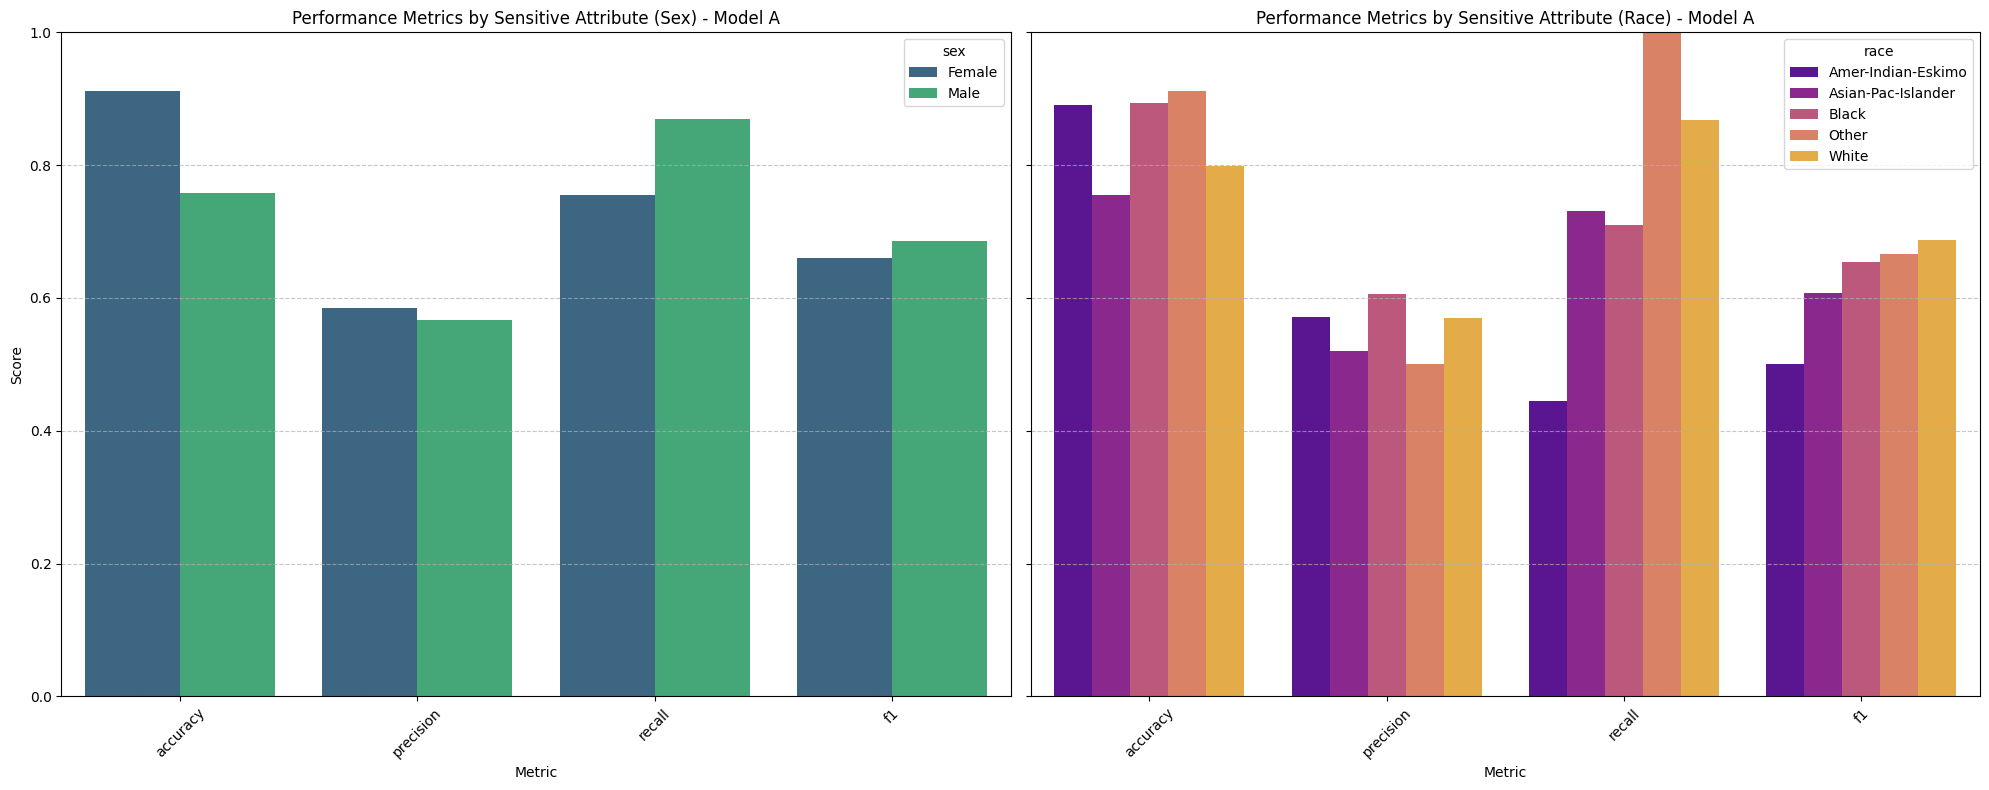


Phase 3 (Model A) complete. Performance and fairness metrics calculated and visualized.


In [ ]:
# Phase 3: Viewpoint A Implementation (The "Data is King" Realist)
# Mitigation (Data Augmentation): Apply a resampling technique to the training data only.

!pip install imbalanced-learn

import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from fairlearn.metrics import MetricFrame, demographic_parity_difference, equalized_odds_difference
import matplotlib.pyplot as lt
import seaborn as sns

print("### Phase 3: Viewpoint A (Data Augmentation - SMOTE) ###")

# 1. Apply SMOTE to the training data to balance the target variable (income)
# X_train_processed is a sparse matrix, SMOTE usually handles sparse matrices, but converting to dense is safer if issues arise.
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

print(f"Original training target distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Resampled training target distribution:\n{y_train_resampled.value_counts(normalize=True)}")

# 2. Train a new model (same architecture as the baseline) on this newly balanced training dataset
model_C = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
model_C.fit(X_train_resampled, y_train_resampled)

# Make predictions on the original, unmodified test set
y_pred_C = model_C.predict(X_test_processed)

print("\n### Evaluate Overall Performance (Model A) ###")

# Evaluate Performance: Calculate overall accuracy, precision, recall, and F1-score
accuracy_C = accuracy_score(y_test, y_pred_C)
precision_C = precision_score(y_test, y_pred_C)
recall_C = recall_score(y_test, y_pred_C)
f1_C = f1_score(y_test, y_pred_C)

print(f"Overall Accuracy (Model A): {accuracy_C:.4f}")
print(f"Overall Precision (Model A): {precision_C:.4f}")
print(f"Overall Recall (Model A): {recall_C:.4f}")
print(f"Overall F1-Score (Model A): {f1_C:.4f}")

print("\n### Evaluate Fairness (Model A) ###")

# We need the sensitive attribute values from the *unprocessed* test set
sensitive_features_test_sex = X_test[SENSITIVE_ATTRIBUTE]
sensitive_features_test_race = X_test['race']

# Create MetricFrames to compute metrics across sensitive groups
metric_frame_C_sex = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'precision': precision_score,
        'recall': recall_score,
        'f1': f1_score
    },
    y_true=y_test,
    y_pred=y_pred_C,
    sensitive_features=sensitive_features_test_sex
)

metric_frame_C_race = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'precision': precision_score,
        'recall': recall_score,
        'f1': f1_score
    },
    y_true=y_test,
    y_pred=y_pred_C,
    sensitive_features=sensitive_features_test_race
)

print("Fairness Metrics by Sensitive Attribute Group (Sex) - Model A:")
display(metric_frame_C_sex.by_group)

print("\nFairness Metrics by Sensitive Attribute Group (Race) - Model A:")
display(metric_frame_C_race.by_group)

# Calculate difference metrics separately
dp_difference_C_sex = demographic_parity_difference(y_test, y_pred_C, sensitive_features=sensitive_features_test_sex)
eo_difference_C_sex = equalized_odds_difference(y_test, y_pred_C, sensitive_features=sensitive_features_test_sex)

dp_difference_C_race = demographic_parity_difference(y_test, y_pred_C, sensitive_features=sensitive_features_test_race)
eo_difference_C_race = equalized_odds_difference(y_test, y_pred_C, sensitive_features=sensitive_features_test_race)

print("\nFairness Differences (Sex) - Model A:")
print(f"Demographic Parity Difference (Sex): {dp_difference_C_sex:.4f}")
print(f"Equalized Odds Difference (Sex): {eo_difference_C_sex:.4f}")

print("\nFairness Differences (Race) - Model A:")
print(f"Demographic Parity Difference (Race): {dp_difference_C_race:.4f}")
print(f"Equalized Odds Difference (Race): {eo_difference_C_race:.4f}")

print("\n### Visualizing Fairness Disparities (Model A) ###")

# Convert MetricFrame.by_group (sex) to a DataFrame for easier plotting
fairness_df_C_sex = metric_frame_C_sex.by_group.reset_index()
fairness_df_C_sex = fairness_df_C_sex.melt(id_vars='sex', var_name='Metric', value_name='Score')

# Convert MetricFrame.by_group for 'race' to a DataFrame for easier plotting
fairness_df_C_race = metric_frame_C_race.by_group.reset_index()
fairness_df_C_race = fairness_df_C_race.melt(id_vars='race', var_name='Metric', value_name='Score')

# Create a figure with two subplots
fig_C, axes_C = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

# Plot for 'sex' disparity
sns.barplot(x='Metric', y='Score', hue='sex', data=fairness_df_C_sex, palette='viridis', ax=axes_C[0])
axes_C[0].set_title('Performance Metrics by Sensitive Attribute (Sex) - Model A')
axes_C[0].set_ylabel('Score')
axes_C[0].set_xlabel('Metric')
axes_C[0].set_ylim(0, 1) # Metrics are usually between 0 and 1
axes_C[0].grid(axis='y', linestyle='--', alpha=0.7)
axes_C[0].tick_params(axis='x', rotation=45)

# Plot for 'race' disparity
sns.barplot(x='Metric', y='Score', hue='race', data=fairness_df_C_race, palette='plasma', ax=axes_C[1])
axes_C[1].set_title('Performance Metrics by Sensitive Attribute (Race) - Model A')
axes_C[1].set_ylabel('Score')
axes_C[1].set_xlabel('Metric')
axes_C[1].set_ylim(0, 1)
axes_C[1].grid(axis='y', linestyle='--', alpha=0.7)
axes_C[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nPhase 3 (Model A) complete. Performance and fairness metrics calculated and visualized.")

## Phase 4: Viewpoint D Implementation (The "Algorithmic Activist")

This phase addresses the argument that balancing data alone is insufficient, as other features can act as proxies for sensitive attributes. We'll use an in-processing fairness mitigation technique from Fairlearn (`ExponentiatedGradient`) to train a model that optimizes for accuracy subject to a fairness constraint.

### Phase 4: Viewpoint D (In-Processing Mitigation - ExponentiatedGradient) ###

### Evaluate Overall Performance (Model B) ###
Overall Accuracy (Model B): 0.8363
Overall Precision (Model B): 0.7221
Overall Recall (Model B): 0.5204
Overall F1-Score (Model B): 0.6049

### Evaluate Fairness (Model B) ###
Fairness Metrics by Sensitive Attribute Group (Sex) - Model B:


,accuracy,precision,recall,f1
sex,,,,
Female,0.898054,0.534626,0.787755,0.636964
Male,0.805741,0.810143,0.470899,0.595602



Fairness Metrics by Sensitive Attribute Group (Race) - Model B:


,accuracy,precision,recall,f1
race,,,,
Amer-Indian-Eskimo,0.917808,0.800000,0.444444,0.571429
Asian-Pac-Islander,0.780000,0.586957,0.519231,0.551020
Black,0.876133,0.587302,0.397849,0.474359
Other,0.955556,0.750000,0.750000,0.750000
White,0.831556,0.736166,0.528369,0.615194



Fairness Differences (Sex) - Model B:
Demographic Parity Difference (Sex): 0.0093
Equalized Odds Difference (Sex): 0.3169

Fairness Differences (Race) - Model B:
Demographic Parity Difference (Race): 0.1615
Equalized Odds Difference (Race): 0.3522

### Visualizing Fairness Disparities (Model B) ###


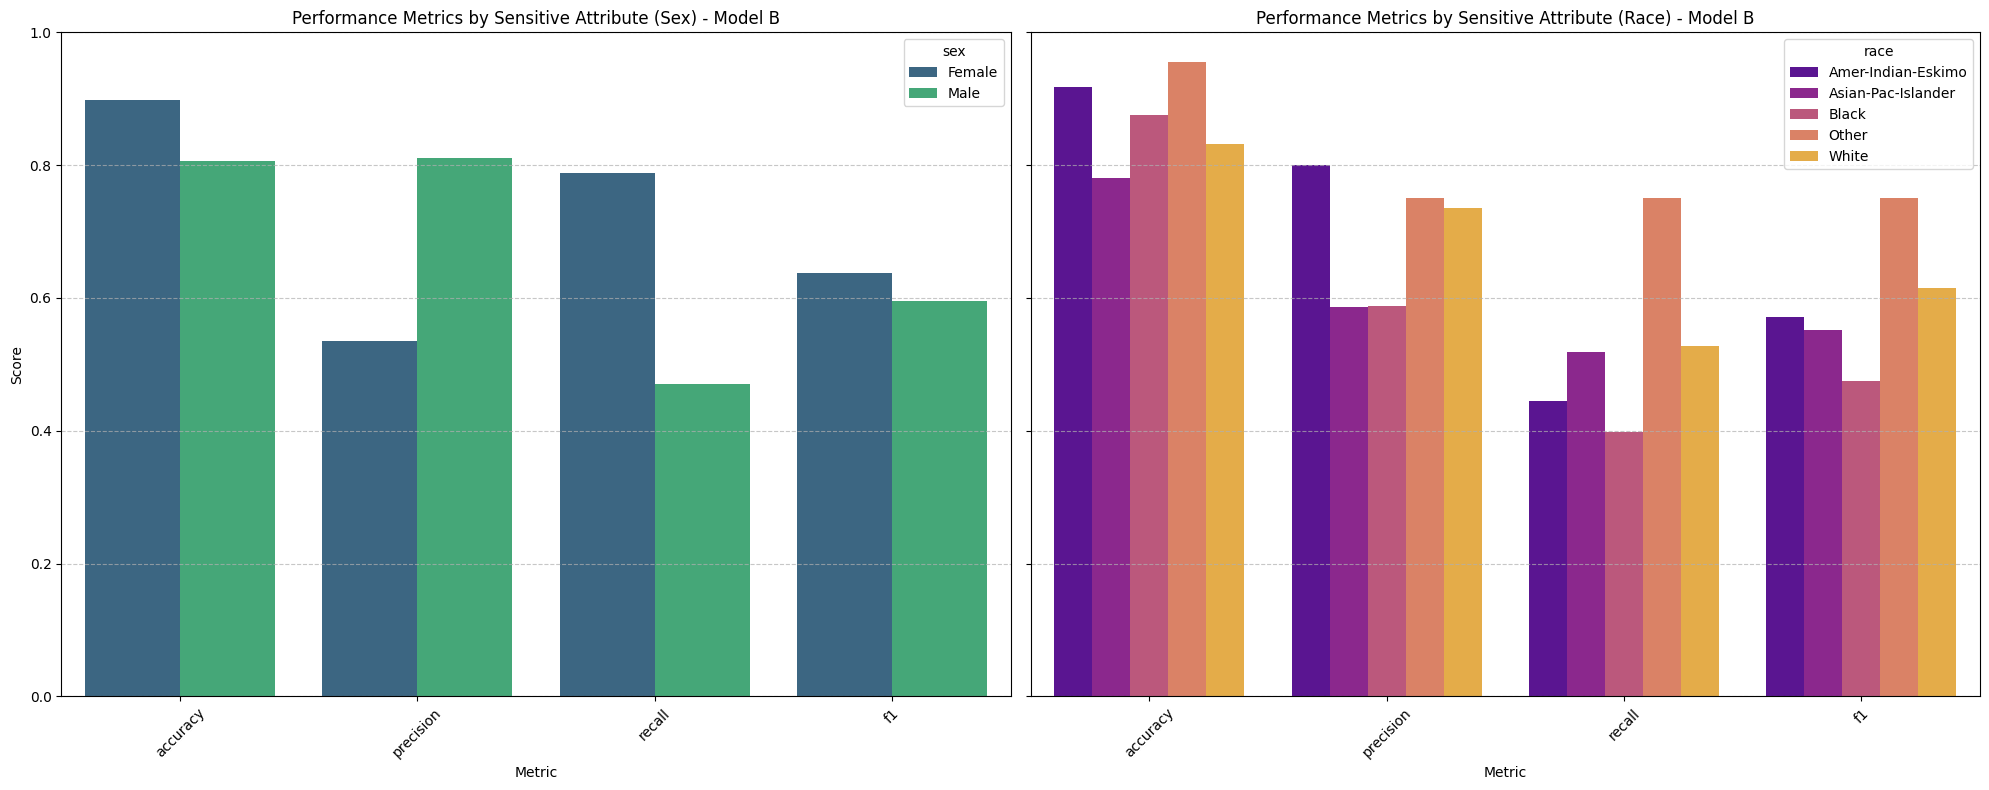


Phase 4 (Model B) complete. Performance and fairness metrics calculated and visualized.


In [ ]:
# Phase 4: Viewpoint D Implementation (The "Algorithmic Activist")
# Mitigation (In-Processing): Use Fairlearn. Wrap your baseline model in ExponentiatedGradient.

from fairlearn.reductions import ExponentiatedGradient, DemographicParity, EqualizedOdds
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from fairlearn.metrics import MetricFrame, demographic_parity_difference, equalized_odds_difference
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Import pandas for DataFrame conversion

print("### Phase 4: Viewpoint D (In-Processing Mitigation - ExponentiatedGradient) ###")

# 1. Define the underlying estimator (same as baseline)
estimator_D = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)

# Get feature names from preprocessor to create DataFrame for Fairlearn reductions
try:
    # Get feature names after one-hot encoding for categorical features
    onehot_features = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
    # Combine numerical and one-hot encoded categorical feature names
    all_features = numerical_features + list(onehot_features)
    # Convert processed arrays to dense NumPy arrays first, then to DataFrames with proper column names
    X_train_processed_df = pd.DataFrame(X_train_processed.toarray(), columns=all_features)
    X_test_processed_df = pd.DataFrame(X_test_processed.toarray(), columns=all_features)
except Exception as e:
    print(f"Warning: Could not get detailed feature names for processed data. Using generic names. Error: {e}")
    # Fallback if get_feature_names_out() not available or other issue
    num_cols_train = X_train_processed.shape[1]
    X_train_processed_df = pd.DataFrame(X_train_processed.toarray(), columns=[f'feature_{i}' for i in range(num_cols_train)])
    num_cols_test = X_test_processed.shape[1]
    X_test_processed_df = pd.DataFrame(X_test_processed.toarray(), columns=[f'feature_{i}' for i in range(num_cols_test)])

# Using 'sex' as the sensitive attribute for mitigation during training
sensitive_features_train_D = X_train[SENSITIVE_ATTRIBUTE]

# 2. Set the Constraint: Use ExponentiatedGradient with DemographicParity constraint
mitigator_D = ExponentiatedGradient(estimator=estimator_D,
                                    constraints=DemographicParity())

# Train this constrained model on the original, unbalanced training dataset
mitigator_D.fit(X_train_processed_df, y_train, sensitive_features=sensitive_features_train_D)

# Make predictions on the original test set
y_pred_D = mitigator_D.predict(X_test_processed_df)

print("\n### Evaluate Overall Performance (Model B) ###")

# Evaluate Performance: Calculate overall accuracy, precision, recall, and F1-score
accuracy_D = accuracy_score(y_test, y_pred_D)
precision_D = precision_score(y_test, y_pred_D)
recall_D = recall_score(y_test, y_pred_D)
f1_D = f1_score(y_test, y_pred_D)

print(f"Overall Accuracy (Model B): {accuracy_D:.4f}")
print(f"Overall Precision (Model B): {precision_D:.4f}")
print(f"Overall Recall (Model B): {recall_D:.4f}")
print(f"Overall F1-Score (Model B): {f1_D:.4f}")

print("\n### Evaluate Fairness (Model B) ###")

# We need the sensitive attribute values from the *unprocessed* test set for evaluation
sensitive_features_test_sex = X_test[SENSITIVE_ATTRIBUTE]
sensitive_features_test_race = X_test['race']

# Create MetricFrames to compute metrics across sensitive groups
metric_frame_D_sex = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'precision': precision_score,
        'recall': recall_score,
        'f1': f1_score
    },
    y_true=y_test,
    y_pred=y_pred_D,
    sensitive_features=sensitive_features_test_sex
)

metric_frame_D_race = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'precision': precision_score,
        'recall': recall_score,
        'f1': f1_score
    },
    y_true=y_test,
    y_pred=y_pred_D,
    sensitive_features=sensitive_features_test_race
)

print("Fairness Metrics by Sensitive Attribute Group (Sex) - Model B:")
display(metric_frame_D_sex.by_group)

print("\nFairness Metrics by Sensitive Attribute Group (Race) - Model B:")
display(metric_frame_D_race.by_group)

# Calculate difference metrics separately
dp_difference_D_sex = demographic_parity_difference(y_test, y_pred_D, sensitive_features=sensitive_features_test_sex)
eo_difference_D_sex = equalized_odds_difference(y_test, y_pred_D, sensitive_features=sensitive_features_test_sex)

dp_difference_D_race = demographic_parity_difference(y_test, y_pred_D, sensitive_features=sensitive_features_test_race)
eo_difference_D_race = equalized_odds_difference(y_test, y_pred_D, sensitive_features=sensitive_features_test_race)

print("\nFairness Differences (Sex) - Model B:")
print(f"Demographic Parity Difference (Sex): {dp_difference_D_sex:.4f}")
print(f"Equalized Odds Difference (Sex): {eo_difference_D_sex:.4f}")

print("\nFairness Differences (Race) - Model B:")
print(f"Demographic Parity Difference (Race): {dp_difference_D_race:.4f}")
print(f"Equalized Odds Difference (Race): {eo_difference_D_race:.4f}")

print("\n### Visualizing Fairness Disparities (Model B) ###")

# Convert MetricFrame.by_group (sex) to a DataFrame for easier plotting
fairness_df_D_sex = metric_frame_D_sex.by_group.reset_index()
fairness_df_D_sex = fairness_df_D_sex.melt(id_vars='sex', var_name='Metric', value_name='Score')

# Convert MetricFrame.by_group for 'race' to a DataFrame for easier plotting
fairness_df_D_race = metric_frame_D_race.by_group.reset_index()
fairness_df_D_race = fairness_df_D_race.melt(id_vars='race', var_name='Metric', value_name='Score')

# Create a figure with two subplots
fig_D, axes_D = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

# Plot for 'sex' disparity
sns.barplot(x='Metric', y='Score', hue='sex', data=fairness_df_D_sex, palette='viridis', ax=axes_D[0])
axes_D[0].set_title('Performance Metrics by Sensitive Attribute (Sex) - Model B')
axes_D[0].set_ylabel('Score')
axes_D[0].set_xlabel('Metric')
axes_D[0].set_ylim(0, 1)
axes_D[0].grid(axis='y', linestyle='--', alpha=0.7)
axes_D[0].tick_params(axis='x', rotation=45)

# Plot for 'race' disparity
sns.barplot(x='Metric', y='Score', hue='race', data=fairness_df_D_race, palette='plasma', ax=axes_D[1])
axes_D[1].set_title('Performance Metrics by Sensitive Attribute (Race) - Model B')
axes_D[1].set_ylabel('Score')
axes_D[1].set_xlabel('Metric')
axes_D[1].set_ylim(0, 1)
axes_D[1].grid(axis='y', linestyle='--', alpha=0.7)
axes_D[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nPhase 4 (Model B) complete. Performance and fairness metrics calculated and visualized.")

## Phase 5
This phase compiles the findings from all 3 models into a comparative table in order to asses the efficacy of each fairness strategy.

## Phase 5: Evaluation and 'The Debate' Visualization

### Comparative Analysis of Models ###


,Model,Overall Accuracy,Overall Precision,Overall Recall,Overall F1-Score,DP Diff (Sex),EO Diff (Sex),DP Diff (Race),EO Diff (Race)
0,Baseline,0.8554,0.7393,0.6167,0.6725,0.1784,0.0827,0.2139,0.6667
1,Model A (SMOTE),0.8093,0.5695,0.8514,0.6825,0.3192,0.2211,0.2921,0.5556
2,Model B (ExponentiatedGradient),0.8363,0.7221,0.5204,0.6049,0.0093,0.3169,0.1615,0.3522


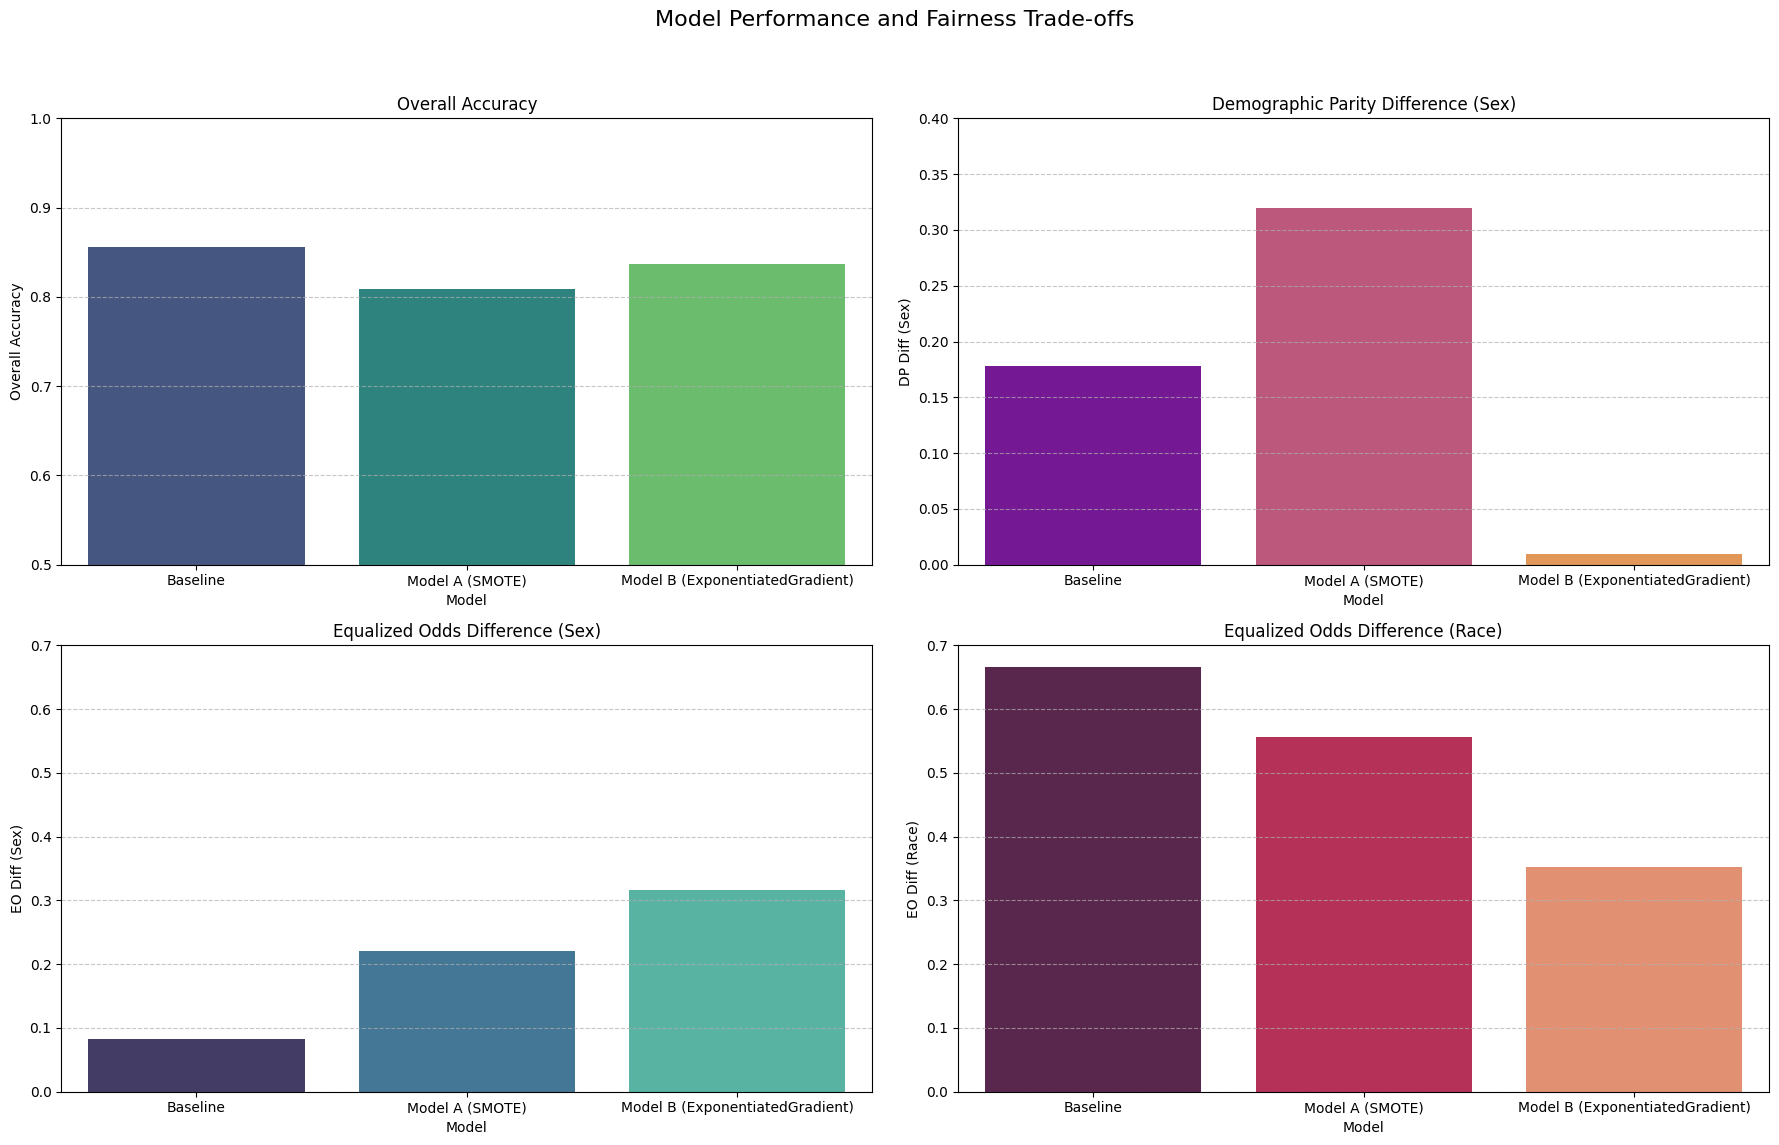

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("## Phase 5: Evaluation and 'The Debate' Visualization")

# 1. Compile results into a comparative table

# Create a dictionary to hold all metrics
results = {
    'Model': ['Baseline', 'Model A (SMOTE)', 'Model B (ExponentiatedGradient)'],
    'Overall Accuracy': [accuracy, accuracy_C, accuracy_D],
    'Overall Precision': [precision, precision_C, precision_D],
    'Overall Recall': [recall, recall_C, recall_D],
    'Overall F1-Score': [f1, f1_C, f1_D],
    'DP Diff (Sex)': [dp_difference, dp_difference_C_sex, dp_difference_D_sex],
    'EO Diff (Sex)': [eo_difference, eo_difference_C_sex, eo_difference_D_sex],
    'DP Diff (Race)': [dp_difference_race, dp_difference_C_race, dp_difference_D_race],
    'EO Diff (Race)': [eo_difference_race, eo_difference_C_race, eo_difference_D_race]
}

results_df = pd.DataFrame(results)

print("\n### Comparative Analysis of Models ###")
display(results_df.round(4))

# 2. Generate visualizations

# Plotting Accuracy vs. Fairness Metrics
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Model Performance and Fairness Trade-offs', fontsize=16)

# Plot 1: Overall Accuracy
sns.barplot(x='Model', y='Overall Accuracy', data=results_df, ax=axes[0, 0], palette='viridis', hue = 'Model', legend=False)
axes[0, 0].set_title('Overall Accuracy')
axes[0, 0].set_ylim(0.5, 1.0)
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Demographic Parity Difference (Sex)
sns.barplot(x='Model', y='DP Diff (Sex)', data=results_df, ax=axes[0, 1], palette='plasma', hue = 'Model', legend=False)
axes[0, 1].set_title('Demographic Parity Difference (Sex)')
axes[0, 1].set_ylim(0, 0.4)
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 3: Equalized Odds Difference (Sex)
sns.barplot(x='Model', y='EO Diff (Sex)', data=results_df, ax=axes[1, 0], palette='mako', hue = 'Model', legend=False)
axes[1, 0].set_title('Equalized Odds Difference (Sex)')
axes[1, 0].set_ylim(0, 0.7)
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 4: Equalized Odds Difference (Race) - as per user's discussion focus
sns.barplot(x='Model', y='EO Diff (Race)', data=results_df, ax=axes[1, 1], palette='rocket', hue = 'Model', legend=False)
axes[1, 1].set_title('Equalized Odds Difference (Race)')
axes[1, 1].set_ylim(0, 0.7)
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()
